Feature Engineering on `areaWithType`, `additionalRoom`, `agePossession`, `furnishDetails` and `features` Columns

## Importing Libraries and Data

In [199]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ast
import re

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [200]:
df = pd.read_csv('A:/CODES/PROJECTS/appartments/Data/gurgaon/properties_cleaned_v1.csv')
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,signature global solera,sector 107,0.36,6581.0,547.0,Carpet area: 547 (50.82 sq.m.),2,2,2,not available,8.0,South-East,1 to 5 Year Old,"['Gurgaon Dreamz Mall', 'Dwarka Expressway', ""Colonel's Central Academy"", 'The NorthCap University', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Trident Hotel Gurgaon', 'Fun N Food Village', 'DLF Golf and Country Club', 'F9 Go Karting Gurgaon', 'SkyJumper Trampoline Park Gurgaon']","['1 Fan', '1 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park', 'Natural Light', 'Airy Rooms', 'Fitness Centre / GYM', 'Waste Disposal']"


## 1. areaWithType

- `Super Built up area`: Total saleable area, including the apartment’s carpet area plus proportionate share of common areas such as lobby, lift, staircase, clubhouse, and corridors.
- `Built Up area`: Carpet area plus the thickness of internal and external walls, and may include private balcony or terrace depending on builder convention.
- `Carpet area`: Net usable floor area inside the apartment where you can lay a carpet, excluding external walls, common areas, service shafts, and usually balconies/terraces.
- `Plot area`: The total area of the land on which the building is constructed, including the footprint of the building and any open spaces within the plot boundary.

`area` column is inconsistent and can contain any of the above area types.

areaWithType contains area with different units like sq.ft, sq.yds, sq.m, etc.

Creating three new columns - `superBuiltUpArea`, `builtUpArea` and `carpetArea`

In [201]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
2224,3.15,3750.0,Super Built up area 3750(348.39 sq.m.)Built Up area: 3200 sq.ft. (297.29 sq.m.)Carpet area: 2444.94 sq.ft. (227.14 sq.m.)
2452,1.25,1806.0,Carpet area: 1806 (167.78 sq.m.)
2436,0.85,1233.0,Carpet area: 1450 (134.71 sq.m.)
1349,1.25,1844.0,Super Built up area 1844(171.31 sq.m.)
327,1.40,1424.0,Super Built up area 1424(132.29 sq.m.)


In [202]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [203]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [204]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [205]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [206]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2362,1.25,flat,1385.0,Built Up area: 1385 (128.67 sq.m.)Carpet area: 1000 sq.ft. (92.9 sq.m.),NaN,1385.0,1000.0
1268,1.90,flat,1800.0,Super Built up area 1920(178.37 sq.m.)Built Up area: 1850 sq.ft. (171.87 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.),1920.0,1850.0,1800.0
646,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,NaN,NaN
189,2.65,flat,2047.0,Super Built up area 2047(190.17 sq.m.)Built Up area: 1900 sq.ft. (176.52 sq.m.)Carpet area: 1700 sq.ft. (157.94 sq.m.),2047.0,1900.0,1700.0
3703,1.12,flat,1567.0,Super Built up area 1572(146.04 sq.m.)Built Up area: 1325 sq.ft. (123.1 sq.m.)Carpet area: 1200 sq.ft. (111.48 sq.m.),1572.0,1325.0,1200.0


In [207]:
df.duplicated().sum()

np.int64(120)

In [208]:
# Checking for rows where all three area columns are not null
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
18,0.35,flat,500.0,Super Built up area 567(52.68 sq.m.)Built Up area: 556 sq.ft. (51.65 sq.m.)Carpet area: 500 sq.ft. (46.45 sq.m.),567.0,556.0,500.0
23,1.59,flat,1929.0,Super Built up area 1929(179.21 sq.m.)Built Up area: 1700 sq.ft. (157.94 sq.m.)Carpet area: 1548 sq.ft. (143.81 sq.m.),1929.0,1700.0,1548.0
29,1.17,flat,1760.0,Super Built up area 1760(163.51 sq.m.)Built Up area: 1186 sq.ft. (110.18 sq.m.)Carpet area: 1130 sq.ft. (104.98 sq.m.),1760.0,1186.0,1130.0
32,1.45,flat,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up area: 1800 sq.ft. (167.23 sq.m.)Carpet area: 1700 sq.ft. (157.94 sq.m.),1900.0,1800.0,1700.0
34,1.55,flat,1800.0,Super Built up area 2000(185.81 sq.m.)Built Up area: 1900 sq.ft. (176.52 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.),2000.0,1900.0,1800.0


In [209]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [210]:
# Checking for rows where areaWithType contains 'Plot'
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
4,3.85,house,2628.0,Plot area 292(244.15 sq.m.),NaN,NaN,NaN
7,12.00,house,2844.0,Plot area 316(264.22 sq.m.),NaN,NaN,NaN
11,2.00,house,646.0,Plot area 60Built Up area: 60 sq.m.Carpet area: 59 sq.m.,NaN,60.0,59.0
24,2.80,house,2250.0,Plot area 2250(209.03 sq.m.),NaN,NaN,NaN
25,5.70,house,3870.0,Plot area 430(359.53 sq.m.)Built Up area: 4550 sq.yards (3804.38 sq.m.)Carpet area: 4450 sq.yards (3720.77 sq.m.),NaN,4550.0,4450.0


In [211]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [212]:
# fetching rows where all three area columns are null
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
4,3.85,house,2628.0,Plot area 292(244.15 sq.m.),NaN,NaN,NaN
7,12.00,house,2844.0,Plot area 316(264.22 sq.m.),NaN,NaN,NaN
24,2.80,house,2250.0,Plot area 2250(209.03 sq.m.),NaN,NaN,NaN
44,NaN,house,NaN,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
53,4.60,house,3771.0,Plot area 419(350.34 sq.m.),NaN,NaN,NaN


In [213]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [214]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [215]:
# filling plot area of houses into built_up_area column
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)
all_nan_df.shape

(546, 7)

In [216]:
# plot area in areaWithType column is not equal to area column as plot area is in yards
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
2485,0.85,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.0,NaN
552,5.70,house,5400.0,Plot area 600(501.68 sq.m.),NaN,600.0,NaN
7,12.00,house,2844.0,Plot area 316(264.22 sq.m.),NaN,316.0,NaN
3032,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,270.0,NaN
2150,2.68,house,1557.0,Plot area 173(144.65 sq.m.),NaN,173.0,NaN


In [217]:
# converting plot area from yards and sq m to sqft
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [218]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)
all_nan_df.shape

(546, 7)

In [219]:
all_nan_df.sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1913,3.15,house,1548.0,Plot area 172(143.81 sq.m.),NaN,1548.0,NaN
1912,7.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.0,NaN
3474,3.51,house,2844.0,Plot area 316(264.22 sq.m.),NaN,2844.0,NaN
3528,0.80,house,1200.0,Plot area 1200(111.48 sq.m.),NaN,1200.0,NaN
1435,4.70,house,2610.0,Plot area 290(242.48 sq.m.),NaN,2610.0,NaN


In [220]:
# update the original dataframe
df.update(all_nan_df)

In [221]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [222]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
344,flat,the lions cghs,sector 56,2.05,9534.0,2150.0,Super Built up area 2150(199.74 sq.m.)Built Up area: 2000 sq.ft. (185.81 sq.m.)Carpet area: 1950 sq.ft. (181.16 sq.m.),4,4,3,"servant room,others",7.0,West,1 to 5 Year Old,"['Sector metro station', 'Sector metro station', 'Sector 54 chowk metro station', 'Sanatan Dharm Mandir', 'Radhakrishna Shani Mandir', 'State bank ATM', 'Icici bank ATM', 'Icici bank ATM', 'Citi bank ATM', 'Indusind bank ATM', 'Surgicare Hospital Gurgaon', 'Kriti Hospital', 'Anand Hospital Gurgaon', 'pracksht hospital', 'Arunodaya Deseret Eye Hospital', 'HUDA Office Complex', 'Medisca', 'Apollo Pharmacy', 'Intellion Park', 'International Tech Park', 'Heera Fuel Station', 'HCG CNG Station', 'Hdfc bank and atm', 'State bank of india', 'Kotak mahindra bank', 'Indusind bank', 'Axis bank', 'Icici bank', 'Hdfc bank', 'Hdfc bank & atm', 'Hdfc bank', '222', 'Pizza Hut', 'Wat-a-Burger', 'Burger Singh', 'Bikanerwala', 'Naivedyam Restaurant', 'Clock tower', 'Starbucks', ""Carl's Jr."", 'Cafe Tonini', 'Sagar Ratna', 'IILM', 'Iilm University', 'Sushant College of Arts & Architecture', 'Ansal Institute of Technology', 'Suncity School']","['4 Wardrobe', '4 Fan', '1 Exhaust Fan', '4 Geyser', '13 Light', '1 Modular Kitchen', '1 AC', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",2150.0,2000.0,1950.0
800,flat,tata primanti,sector 72,3.19,12152.0,2625.0,Super Built up area 2625(243.87 sq.m.),4,5,3+,servant room,20.0,North,1 to 5 Year Old,"['Sector 55-56 Metro Station', 'Omaxe City Centre', 'Sohna Gurgaon Road', 'Faridabad Gurgaon Road', 'Pallavan PreSchool, Sohna Road', 'RBSM Public school', 'Polaris Hospital', 'Spaze Itech Park', 'Radisson Hotel Gurugram Sohna Road', 'SkyJumper Trampoline Park Gurgaon']","['3 Wardrobe', '8 Fan', '1 Exhaust Fan', '1 Stove', '15 Light', '1 Chimney', '6 AC', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2625.0,NaN,NaN
2126,flat,ss the leaf,sector 85,2.13,7574.0,2812.0,Super Built up area 2812(261.24 sq.m.)Built Up area: 2600 sq.ft. (241.55 sq.m.)Carpet area: 2200 sq.ft. (204.39 sq.m.),4,4,3,not available,2.0,North,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Central Peripheral Road', 'NH 08', 'Pataudi Road', 'Delhi Public School Sector 84', 'DPG Institute of Technology', 'Genesis Hospital Sector 84', 'Indira Gandhi International Airport', 'Imt Manesar', 'Holiday Inn Hotel Sector 90', 'SkyJumper Trampoline Park', 'Nakhrola Stadium Sector 81A']","['6 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fi

## 2.additionalRoom

- `study room` : A room in a house used for reading, writing, or academic work.
- `store room` : A room in a house used for storing items.
- `pooja room` : A room in a house used for religious or spiritual activities.
- `servant room` : A room in a house used for the accommodation of servants.
- `others` : Any other type of room not covered by the above categories.

there are to many combination of these rooms so will divide into 5 columns like one-hot encoding

In [223]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
store room                                         99
study room,servant room                            99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
servant room,

In [224]:
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [225]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
171,not available,0,0,0,0,0
30,servant room,0,1,0,0,0
149,servant room,0,1,0,0,0
847,not available,0,0,0,0,0
891,"servant room,pooja room",0,1,0,1,0


## 3.agePossession

In [226]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Jan 2024                 8
Oct 2024                 8
Dec 2025                 7
Jun 2024                 7
Aug 2023                 7
Nov 2023                 5
Aug 2024                 4
Sep 2023                 4
By 2025                  4
Jul 2024                 4
Oct 2023                 4
Nov 2024                 3
May 2024                 3
Jan 2025                 3
Feb 2024                 3
Sep 2025                 2
Dec 2026                 2
Jan 2026                 2
By 2027                  2
Mar 2025                 2
Jun 2027                 2
Jul 2027                 2
Oct 2025                 2
Jul 2025      

In [227]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [228]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [229]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              333
Old Property           310
Under Construction     283
Name: count, dtype: int64

## 4.furnishDetails

furnishDetails column contains 18 unique values which can be split into 18 news columns but i categorized into 4 categories - `furnished`, `semi-furnished`, `unfurnished` and `others`.

In [230]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
862,[],NaN
1450,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '3 Geyser', '5 Light', '1 Chimney', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
14,NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Visitor Parking', 'Park', 'Security Personnel', 'Natural Light', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
1554,NaN,"['Lift(s)', 'Park']"
1957,"['1 Fan', '1 Geyser', '1 Chimney', '1 Modular Kitchen', '2 Wardrobe', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"


In [231]:
# Extract all unique furnishings from the furnishDetails column and converting into 18 new columns
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]
furnishings_df.shape

(3803, 19)

In [232]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

In [233]:
furnishings_df.sample(5)

,Washing Machine,Curtains,Water Purifier,AC,Exhaust Fan,Light,Wardrobe,Dining Table,Bed,Microwave,Chimney,Fridge,Stove,Sofa,TV,Geyser,Modular Kitchen,Fan
3113,0,0,0,0,1,5,2,0,0,0,0,0,0,0,0,0,0,4
1302,0,0,0,3,0,12,0,0,0,0,1,0,1,0,0,2,1,0
2703,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2647,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
425,0,0,0,3,0,5,0,0,0,0,0,0,0,0,0,0,0,5


Clustering the group the similar columns together

In [234]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

Elbow method show that 3 clusters are optimal for our data.

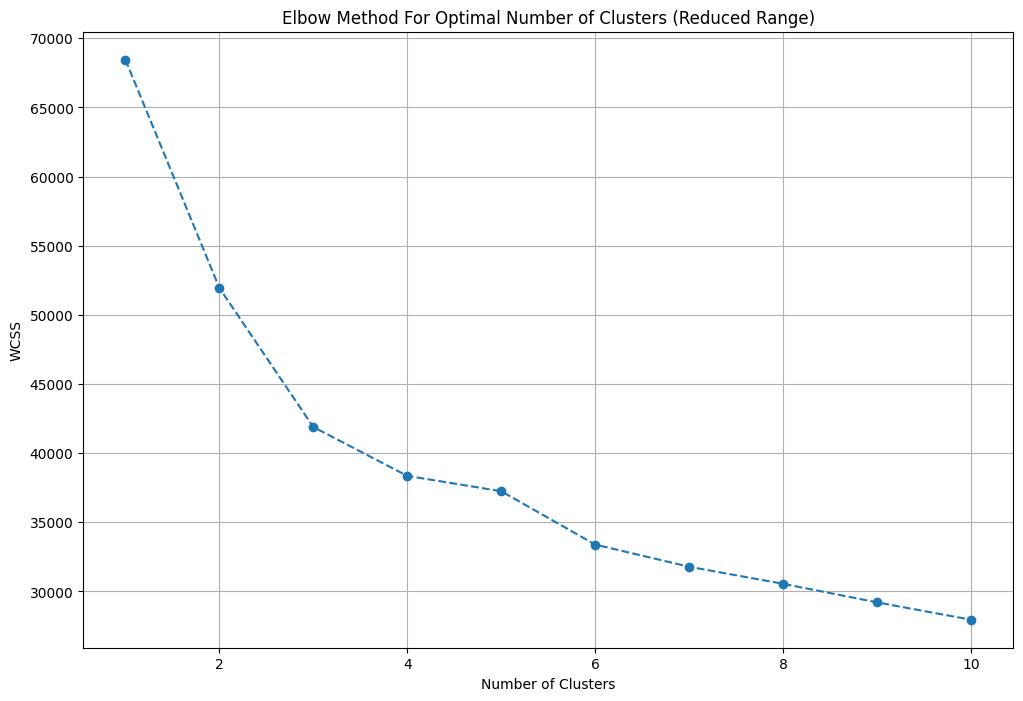

In [235]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [236]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [237]:
df = df.iloc[:,:-18]

In [238]:
df['furnishing_type'] = cluster_assignments

- 0 : unfurnished
- 1 : semifurnished
- 2 : furnished

In [239]:
df.sample(5)[['furnishDetails','furnishing_type']]

,furnishDetails,furnishing_type
849,[],0
129,NaN,0
573,"['4 Fan', '1 Exhaust Fan', '1 Geyser', '8 Light', '1 Curtains', '1 Modular Kitchen', '1 Wardrobe', 'No AC', 'No Bed', 'No Chimney', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",2
454,NaN,0
1595,"['1 Fan', '3 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0


## 5.features

In [240]:
df[['society','features']].sample(5)

,society,features
1861,independent,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Water purifier', 'High Ceiling Height', 'Swimming Pool', 'Separate entry for servant room', 'Park', 'Visitor Parking', 'Natural Light', 'Spacious Interiors']"
1613,chd avenue,"['Intercom Facility', 'Lift(s)', 'Feng Shui / Vaastu Compliant', 'Security Personnel', 'Maintenance Staff', 'Internet/wi-fi connectivity', 'Swimming Pool', 'Park', 'Club house / Community Center', 'Fitness Centre / GYM', 'Water softening plant', 'Rain Water Harvesting', 'Shopping Centre']"
3194,independent,"['Water Storage', 'Waste Disposal']"
1228,adani brahma samsara vilasa,"['Lift(s)', 'Park', 'Piped-gas', 'Natural Light', 'Fitness Centre / GYM', 'Club house / Community Center']"
253,housing apna enclave,NaN


In [241]:
df['features'].isnull().sum()

np.int64(635)

To fill Null values in the features column, we used apartment database and map with society column with PropertyName column.

In [242]:
app_df = pd.read_csv('A:/CODES/PROJECTS/appartments/Data/Data Gathering/Apartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [243]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [244]:
temp_df = df[df['features'].isnull()]
temp_df.shape

(635, 26)

In [245]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [246]:
df.loc[temp_df.index,'features'] = x.values

Null values reduced from 635 to 481

In [247]:
df['features'].isnull().sum()

np.int64(481)

There are total 154 unique features in the features column so we can create 154 new columns with one-hot encoding or we can cluster into categories.

In [248]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)
features_binary_df.shape

(3803, 130)

In [249]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
83,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
344,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
331,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3287,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [250]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10 ,random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

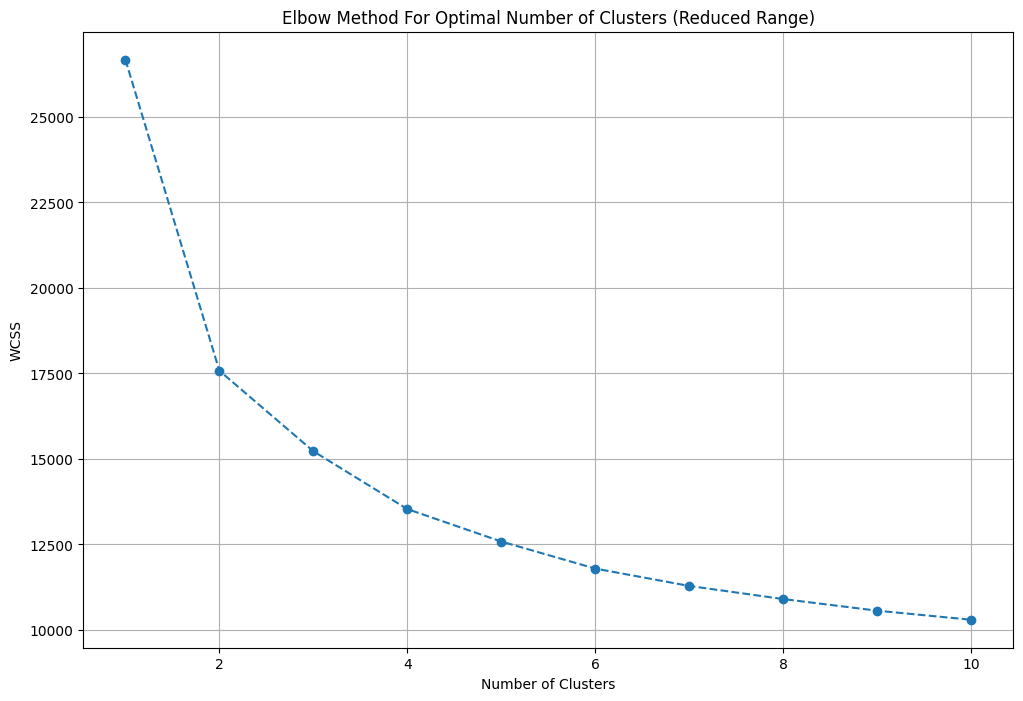

In [251]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

It is giving two clusters one with Nan and rest to other category. It is not good. so try other way.

Define the weights for each feature as provided by assigning weights based on perceived luxury contribution.

In [ ]:
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)
df['luxury_score'] = luxury_score
df.shape


In [255]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1847,flat,ireo the corridors,sector 67a,1.50,11111.0,1350.0,Carpet area: 1350 (125.42 sq.m.),2,2,2,10.0,NaN,Relatively New,NaN,NaN,1350.0,0,0,1,0,0,2,38
468,house,ashok vihar phase 3 gurgaon,sector 3 phase 3 extension,0.95,8878.0,1070.0,Plot area 1070(99.41 sq.m.),4,3,2,1.0,East,Old Property,NaN,1070.0,NaN,0,0,0,0,0,0,8
1055,flat,unitech sunbreeze,sector 69,0.75,6849.0,1095.0,Super Built up area 1095(101.73 sq.m.),2,2,2,4.0,NaN,Under Construction,1095.0,NaN,NaN,0,0,0,0,0,0,0
371,flat,m3m golfestate,sector 65,6.15,15998.0,3844.0,Carpet area: 3844 (357.12 sq.m.),3,5,3+,1.0,West,Relatively New,NaN,NaN,3844.0,0,1,0,0,0,1,49
3477,flat,dlf the ultima,sector 81,2.25,10553.0,2132.0,Super Built up area 2132(198.07 sq.m.),3,3,3+,6.0,East,New Property,2132.0,NaN,NaN,0,1,0,0,0,1,168


## Conclusion

Droping non usefull columns `nearbyLocations`, `furnishDetails`, `features`, `features_list`, `additionalRoom`

In [ ]:
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)
df.shape

In [256]:
df.to_csv('A:/CODES/PROJECTS/appartments/Data/gurgaon/properties_cleaned_v2.csv',index=False)